# Задание 10. Классификация нейронными сетями

Что нужно сделать:
- **Часть 1.** Определить язык текста (русский / английский) по двум признакам — отношение количества слов
  к количеству букв и отношение количества уникальных слов к общему количеству слов. Задача та же, что
  в задании 8, но решается нейросетями, в двух вариантах:
  - **модель 1**: выходных нейронов столько же, сколько классов (2), функция потерь — categorical cross-entropy;
  - **модель 2**: один выходной нейрон с сигмоидой, вероятность второго класса = `1 - p`, функция потерь —
    binary cross-entropy.

  Для обеих моделей построить кривые обучения и цветовую карту классификации, посчитать Accuracy, Precision,
  Recall, F1 и сравнить модели.
- **Часть 2.** Многоклассовая классификация цифр MNIST: 784 входных нейрона, 10 выходных. При обучении
  использовать технику динамического learning rate.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix)

torch.manual_seed(42)
np.random.seed(42)

## Часть 1. Определение языка текста

Берем те же книги, что и в задании 8: «Отцы и дети» Тургенева для русского языка и «Moby Dick» Мелвилла
для английского. Каждый обучающий пример — фрагмент текста длиной от 10 до 100 слов, у которого считаются
два признака.

### Шаг 1. Читаем тексты и чистим их

In [2]:
ru_text = open("../08 задание/texts/ru_otcy_i_deti.txt", encoding="utf-8").read()
en_text = open("../08 задание/texts/en_moby_dick.txt", encoding="utf-8").read()

print("русский текст, символов: ", len(ru_text))
print("английский текст, символов:", len(en_text))
print()
print(ru_text[:200])

русский текст, символов:  355726
английский текст, символов: 1218940

Отцы и дети

Роман

Книга: И. С. Тургенев. «Накануне. Отцы и дети»

Издательство «Художественная литература», Москва, 1979

— Что, Петр, не видать еще? — спрашивал 20-го мая 1859 года, выходя без шапк


Убираем знаки препинания, цифры и всё остальное, что не буква, приводим к нижнему регистру и разбиваем
текст на отдельные слова.

In [3]:
def get_words(text):
    text = text.lower()
    text = re.sub(r"[^а-яёa-z]+", " ", text)   # всё, что не буква, заменяем пробелом
    return text.split()


ru_words = get_words(ru_text)
en_words = get_words(en_text)

print("слов в русском тексте:  ", len(ru_words))
print("слов в английском тексте:", len(en_words))
print(ru_words[:10])
print(en_words[:10])

слов в русском тексте:   54791
слов в английском тексте: 219054
['отцы', 'и', 'дети', 'роман', 'книга', 'и', 'с', 'тургенев', 'накануне', 'отцы']
['moby', 'dick', 'or', 'the', 'whale', 'by', 'herman', 'melville', 'contents', 'etymology']


Английская книга почти в 4 раза длиннее русской, поэтому обрезаем ее до того же числа слов — иначе классы
получатся несбалансированными.

In [4]:
en_words = en_words[:len(ru_words)]
print(len(ru_words), len(en_words))

54791 54791


### Шаг 2. Режем текст на фрагменты и считаем признаки

Идем по списку слов и отрезаем куски случайной длины от 10 до 100 слов. Для каждого куска считаем:

- `words_per_letter` = количество слов / количество букв;
- `uniq_per_word` = количество уникальных слов / количество слов.

In [5]:
def make_fragments(words, label):
    rows = []
    i = 0
    while i + 100 < len(words):
        n = np.random.randint(10, 101)          # длина фрагмента
        frag = words[i:i + n]
        letters = sum(len(w) for w in frag)     # букв во фрагменте
        rows.append([len(frag) / letters, len(set(frag)) / len(frag), label])
        i += n
    return rows


# 0 — русский, 1 — английский
rows = make_fragments(ru_words, 0) + make_fragments(en_words, 1)

df = pd.DataFrame(rows, columns=["words_per_letter", "uniq_per_word", "lang"])
df.head()

,words_per_letter,uniq_per_word,lang
0,0.191223,0.819672,0
1,0.147239,0.833333,0
2,0.188811,0.790123,0
3,0.162413,0.928571,0
4,0.164835,0.933333,0


In [6]:
print("всего фрагментов:", len(df))
print(df["lang"].value_counts())
df.groupby("lang").mean().round(3)

всего фрагментов: 2038
lang
0    1022
1    1016
Name: count, dtype: int64


,words_per_letter,uniq_per_word
lang,,
0,0.199,0.880
1,0.234,0.822


Классы получились почти одинакового размера. Русские фрагменты в среднем имеют меньшее отношение
слов к буквам (0.199 против 0.234) — русские слова длиннее, а уникальных слов у них наоборот больше.
То есть первый признак и должен нести основную информацию.

### Шаг 3. Делим на обучающую и тестовую выборки и масштабируем признаки

Параметры масштабирования (среднее и стандартное отклонение) считаем **только по обучающей выборке**,
иначе информация о тесте протечет в обучение.

In [7]:
X = df[["words_per_letter", "uniq_per_word"]].values.astype(np.float32)
y = df["lang"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train_n = (X_train - mean) / std
X_test_n = (X_test - mean) / std

Xtr = torch.tensor(X_train_n)
Xte = torch.tensor(X_test_n)

print("обучающая:", X_train.shape, " тестовая:", X_test.shape)

обучающая: (1426, 2)  тестовая: (612, 2)


### Шаг 4. Модель 1: два выходных нейрона, categorical cross-entropy

Выходных нейронов столько же, сколько классов. `nn.CrossEntropyLoss` в PyTorch — это и есть categorical
cross-entropy: softmax считается внутри самой функции потерь, поэтому последний слой отдает просто логиты.
Целевые значения — номера классов (0 или 1).

In [8]:
ytr1 = torch.tensor(y_train, dtype=torch.long)
yte1 = torch.tensor(y_test, dtype=torch.long)

model1 = nn.Sequential(
    nn.Linear(2, 8), nn.ReLU(),
    nn.Linear(8, 2),
)
loss_fn1 = nn.CrossEntropyLoss()
opt1 = torch.optim.Adam(model1.parameters(), lr=0.003)

print(model1)

Sequential(
  (0): Linear(in_features=2, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=2, bias=True)
)


In [9]:
epochs = 80
batch = 32

train_loss1, test_loss1 = [], []

for ep in range(epochs):
    idx = torch.randperm(len(Xtr))                 # перемешиваем обучающую выборку
    for i in range(0, len(Xtr), batch):
        b = idx[i:i + batch]
        opt1.zero_grad()
        loss = loss_fn1(model1(Xtr[b]), ytr1[b])
        loss.backward()
        opt1.step()

    # после каждой эпохи считаем ошибку на обеих выборках
    with torch.no_grad():
        train_loss1.append(loss_fn1(model1(Xtr), ytr1).item())
        test_loss1.append(loss_fn1(model1(Xte), yte1).item())

    if (ep + 1) % 10 == 0:
        print(f"эпоха {ep + 1}: train loss = {train_loss1[-1]:.4f}, test loss = {test_loss1[-1]:.4f}")

эпоха 10: train loss = 0.4293, test loss = 0.4460
эпоха 20: train loss = 0.4252, test loss = 0.4407
эпоха 30: train loss = 0.4238, test loss = 0.4378


эпоха 40: train loss = 0.4229, test loss = 0.4372
эпоха 50: train loss = 0.4224, test loss = 0.4352


эпоха 60: train loss = 0.4217, test loss = 0.4361
эпоха 70: train loss = 0.4209, test loss = 0.4343
эпоха 80: train loss = 0.4204, test loss = 0.4343


Вероятности классов получаем из логитов через softmax, прогноз — класс с большей вероятностью.

In [10]:
with torch.no_grad():
    proba1 = torch.softmax(model1(Xte), dim=1).numpy()

pred1 = proba1.argmax(axis=1)

pd.DataFrame({
    "P(рус)": proba1[:5, 0].round(3),
    "P(англ)": proba1[:5, 1].round(3),
    "прогноз": pred1[:5],
    "истина": y_test[:5],
})

,P(рус),P(англ),прогноз,истина
0,0.371,0.629,1,1
1,0.721,0.279,0,1
2,0.921,0.079,0,0
3,0.831,0.169,0,0
4,0.087,0.913,1,1


### Шаг 5. Модель 2: один выходной нейрон с сигмоидой, binary cross-entropy

Здесь выходной нейрон один, на нем сигмоида — она дает вероятность отнесения к классу «английский».
Вероятность второго класса получаем как `1 - p`. Функция потерь — `nn.BCELoss`, целевые значения
должны быть вещественными (0.0 или 1.0).

In [11]:
ytr2 = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
yte2 = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

model2 = nn.Sequential(
    nn.Linear(2, 8), nn.ReLU(),
    nn.Linear(8, 1), nn.Sigmoid(),
)
loss_fn2 = nn.BCELoss()
opt2 = torch.optim.Adam(model2.parameters(), lr=0.003)

print(model2)

Sequential(
  (0): Linear(in_features=2, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=1, bias=True)
  (3): Sigmoid()
)


In [12]:
train_loss2, test_loss2 = [], []

for ep in range(epochs):
    idx = torch.randperm(len(Xtr))
    for i in range(0, len(Xtr), batch):
        b = idx[i:i + batch]
        opt2.zero_grad()
        loss = loss_fn2(model2(Xtr[b]), ytr2[b])
        loss.backward()
        opt2.step()

    with torch.no_grad():
        train_loss2.append(loss_fn2(model2(Xtr), ytr2).item())
        test_loss2.append(loss_fn2(model2(Xte), yte2).item())

    if (ep + 1) % 10 == 0:
        print(f"эпоха {ep + 1}: train loss = {train_loss2[-1]:.4f}, test loss = {test_loss2[-1]:.4f}")

эпоха 10: train loss = 0.4366, test loss = 0.4505
эпоха 20: train loss = 0.4282, test loss = 0.4437


эпоха 30: train loss = 0.4256, test loss = 0.4421
эпоха 40: train loss = 0.4238, test loss = 0.4409
эпоха 50: train loss = 0.4228, test loss = 0.4400


эпоха 60: train loss = 0.4221, test loss = 0.4396


эпоха 70: train loss = 0.4214, test loss = 0.4386
эпоха 80: train loss = 0.4208, test loss = 0.4372


In [13]:
with torch.no_grad():
    p_eng = model2(Xte).numpy().ravel()

p_rus = 1 - p_eng                     # вероятность второго класса
pred2 = (p_eng > 0.5).astype(int)

pd.DataFrame({
    "P(рус) = 1 - p": p_rus[:5].round(3),
    "P(англ) = p": p_eng[:5].round(3),
    "прогноз": pred2[:5],
    "истина": y_test[:5],
})

,P(рус) = 1 - p,P(англ) = p,прогноз,истина
0,0.340,0.660,1,1
1,0.709,0.291,0,1
2,0.940,0.060,0,0
3,0.842,0.158,0,0
4,0.089,0.911,1,1


### Шаг 6. Кривые обучения

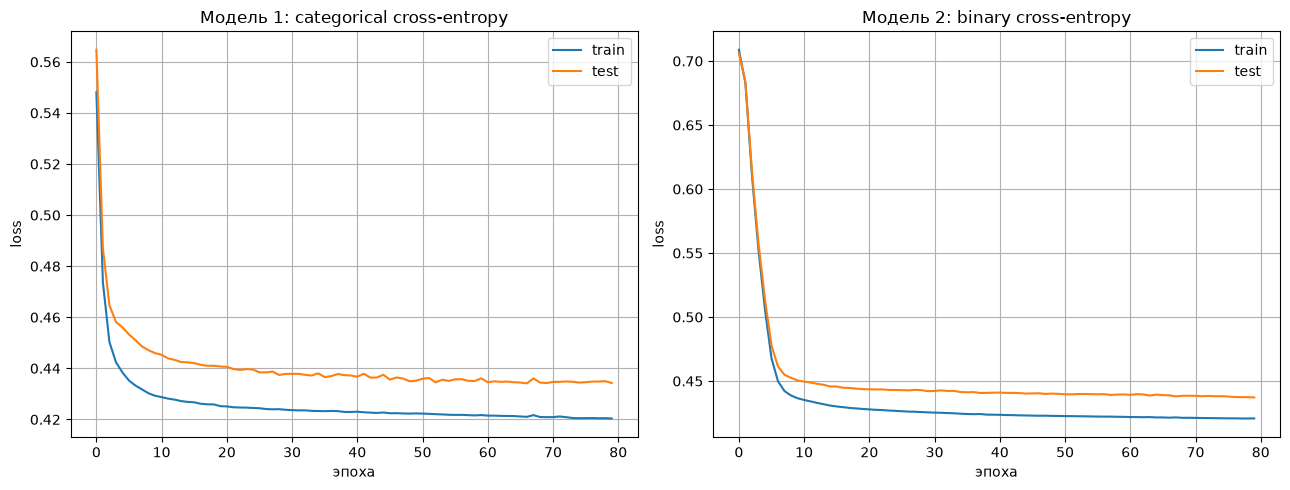

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(train_loss1, label="train")
axes[0].plot(test_loss1, label="test")
axes[0].set_title("Модель 1: categorical cross-entropy")

axes[1].plot(train_loss2, label="train")
axes[1].plot(test_loss2, label="test")
axes[1].set_title("Модель 2: binary cross-entropy")

for ax in axes:
    ax.set_xlabel("эпоха")
    ax.set_ylabel("loss")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

Обе кривые ведут себя одинаково: ошибка быстро падает за первые 5-10 эпох и дальше выходит на плато
около 0.42-0.44. Кривая теста идет чуть выше обучающей, но не растет — переобучения нет, признаков
всего два и модели просто не хватает информации, чтобы опуститься ниже.

### Шаг 7. Цветовая карта классификации

Покрываем плоскость двух признаков сеткой точек, прогоняем каждую точку через модель и раскрашиваем фон
в цвет вероятности класса «английский». Сетку перед подачей в модель масштабируем теми же параметрами,
что и обучающую выборку.

In [15]:
xx, yy = np.meshgrid(np.linspace(0.10, 0.40, 300),
                     np.linspace(0.50, 1.00, 300))
grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
grid_n = torch.tensor((grid - mean) / std)

with torch.no_grad():
    z1 = torch.softmax(model1(grid_n), dim=1)[:, 1].numpy().reshape(xx.shape)
    z2 = model2(grid_n).numpy().reshape(xx.shape)

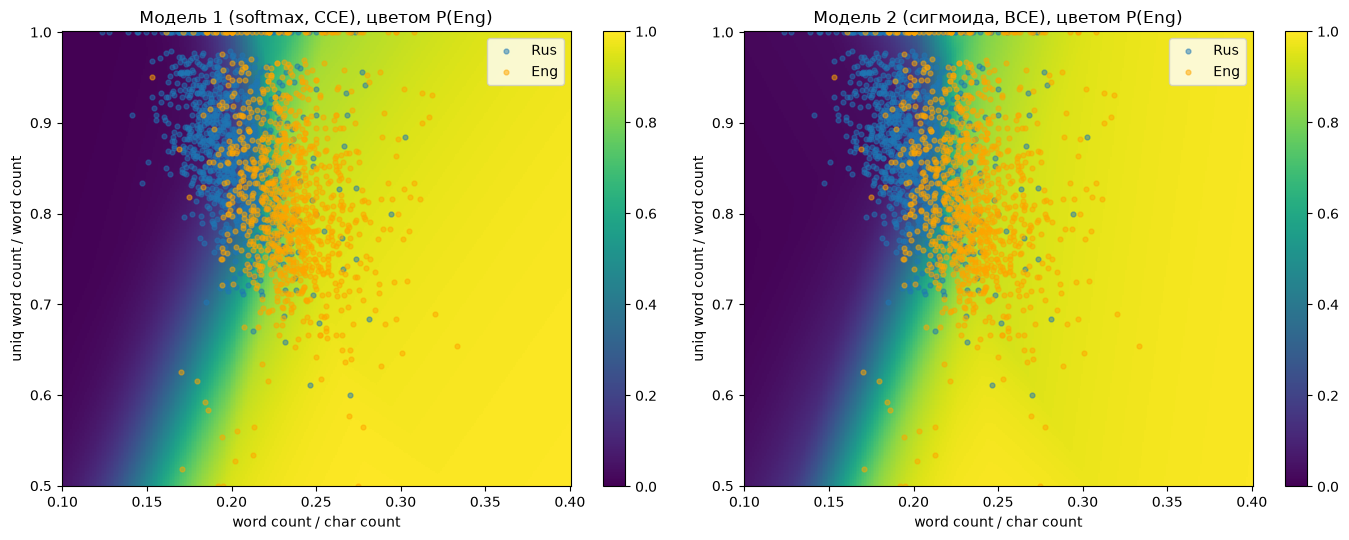

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, z, name in zip(axes, [z1, z2], ["Модель 1 (softmax, CCE)", "Модель 2 (сигмоида, BCE)"]):
    c = ax.pcolormesh(xx, yy, z, cmap="viridis", shading="auto", vmin=0, vmax=1)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], s=12, alpha=0.5, color="tab:blue", label="Rus")
    ax.scatter(X[y == 1, 0], X[y == 1, 1], s=12, alpha=0.5, color="orange", label="Eng")
    ax.set_xlabel("word count / char count")
    ax.set_ylabel("uniq word count / word count")
    ax.set_title(name + ", цветом P(Eng)")
    ax.legend()
    fig.colorbar(c, ax=ax)

plt.tight_layout()
plt.show()

Карты у двух моделей практически неотличимы: граница проходит вертикально примерно по
`word count / char count` = 0.21 и почти не зависит от второго признака. Облака точек двух языков
частично перекрываются в районе границы — именно там и будут все ошибки.

### Шаг 8. Метрики и сравнение моделей

In [17]:
def metrics(y_true, y_pred):
    return [accuracy_score(y_true, y_pred), precision_score(y_true, y_pred),
            recall_score(y_true, y_pred), f1_score(y_true, y_pred)]


res = pd.DataFrame([metrics(y_test, pred1), metrics(y_test, pred2)],
                   index=["Модель 1 (2 нейрона, CCE)", "Модель 2 (1 нейрон, BCE)"],
                   columns=["Accuracy", "Precision", "Recall", "F1"])
res.round(4)

,Accuracy,Precision,Recall,F1
"Модель 1 (2 нейрона, CCE)",0.8088,0.8133,0.8000,0.8066
"Модель 2 (1 нейрон, BCE)",0.8105,0.8119,0.8066,0.8092


In [18]:
print("доля совпавших прогнозов двух моделей:", (pred1 == pred2).mean().round(4))
print()
print("матрица ошибок модели 1 (0 — рус, 1 — англ):")
print(confusion_matrix(y_test, pred1))

доля совпавших прогнозов двух моделей: 0.9951

матрица ошибок модели 1 (0 — рус, 1 — англ):
[[251  56]
 [ 61 244]]


Обе модели дают одинаковый результат: Accuracy около 0.81, остальные метрики тоже совпадают
с точностью до третьего знака, а сами прогнозы расходятся меньше чем на 1% объектов. Это ожидаемо:
для двух классов softmax с двумя нейронами и сигмоида с одним — два способа записать одну и ту же
модель, только у модели 1 параметров на выходном слое в два раза больше. Разница между ними
в пределах случайности инициализации весов, а не в качестве.

Само качество (0.81) ограничено признаками, а не сетью: коротких фрагментов из 10-20 слов слишком мало,
чтобы отношение слов к буквам устоялось, и они попадают в чужую область.

## Часть 2. Многоклассовая классификация цифр MNIST

Датасет в формате csv: первый столбец — метка класса (цифра), остальные 784 — интенсивности пикселей
картинки 28x28. Соответственно в сети 784 входных нейрона и 10 выходных.

### Шаг 1. Загружаем датасет

In [19]:
train_df = pd.read_csv("../mnist/mnist_train.csv")
test_df = pd.read_csv("../mnist/mnist_test.csv")

print("обучающая:", train_df.shape, " тестовая:", test_df.shape)
train_df.iloc[:5, :8]

обучающая: (60000, 785)  тестовая: (10000, 785)


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7
0,5,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0


In [20]:
# пиксели делим на 255, чтобы признаки были в диапазоне [0, 1]
X_train = train_df.drop("label", axis=1).values.astype(np.float32) / 255.0
y_train = train_df["label"].values

X_test = test_df.drop("label", axis=1).values.astype(np.float32) / 255.0
y_test = test_df["label"].values

print(X_train.shape, X_test.shape)
print("пропусков:", train_df.isnull().sum().sum())
print()
print(train_df["label"].value_counts().sort_index())

(60000, 784) (10000, 784)
пропусков: 0

label
0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64


Классы примерно сбалансированы — по 5.5-6.7 тысяч примеров на цифру.

### Шаг 2. Смотрим на картинки

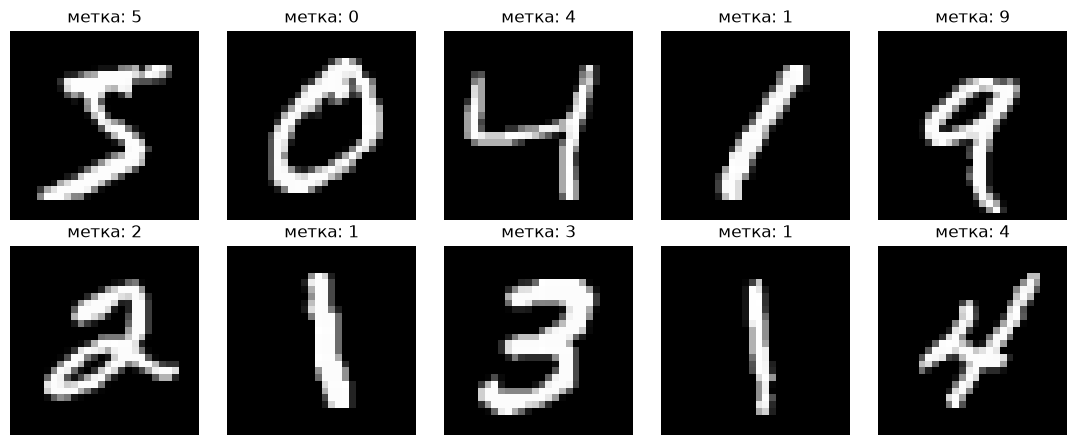

In [21]:
fig, axes = plt.subplots(2, 5, figsize=(11, 4.5))

for ax, i in zip(axes.flatten(), range(10)):
    ax.imshow(X_train[i].reshape(28, 28), cmap="gray")
    ax.set_title("метка: " + str(y_train[i]))
    ax.axis("off")

plt.tight_layout()
plt.show()

### Шаг 3. Строим сеть

Простая сеть из двух линейных слоев: 784 -> 128 -> 10. На скрытом слое ReLU, на выходе 10 логитов,
softmax считается внутри `nn.CrossEntropyLoss`.

In [22]:
Xtr = torch.tensor(X_train)
ytr = torch.tensor(y_train, dtype=torch.long)
Xte = torch.tensor(X_test)
yte = torch.tensor(y_test, dtype=torch.long)

model = nn.Sequential(
    nn.Linear(784, 128), nn.ReLU(),
    nn.Linear(128, 10),
)
loss_fn = nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=10, bias=True)
)


### Шаг 4. Обучение с динамическим learning rate

Динамический learning rate: начинаем с lr = 0.001, а каждые 3 эпохи уменьшаем шаг в 2 раза
(`StepLR` с `gamma=0.5`). Смысл в том, чтобы сначала быстро дойти до нужной области, а ближе к концу
обучения делать мелкие шаги и не «перескакивать» минимум.

In [23]:
scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=3, gamma=0.5)

epochs = 12
batch = 64

train_loss, test_loss, test_acc, lrs = [], [], [], []

for ep in range(epochs):
    lrs.append(opt.param_groups[0]["lr"])       # запоминаем текущий lr

    idx = torch.randperm(len(Xtr))
    running = 0.0
    for i in range(0, len(Xtr), batch):
        b = idx[i:i + batch]
        opt.zero_grad()
        loss = loss_fn(model(Xtr[b]), ytr[b])
        loss.backward()
        opt.step()
        running += loss.item() * len(b)

    scheduler.step()                            # уменьшаем lr по расписанию

    with torch.no_grad():
        out_te = model(Xte)
        train_loss.append(running / len(Xtr))
        test_loss.append(loss_fn(out_te, yte).item())
        test_acc.append((out_te.argmax(dim=1) == yte).float().mean().item())

    print(f"эпоха {ep + 1:2d}: lr = {lrs[-1]:.5f}  train loss = {train_loss[-1]:.4f}  "
          f"test loss = {test_loss[-1]:.4f}  test acc = {test_acc[-1]:.4f}")

эпоха  1: lr = 0.00100  train loss = 0.3397  test loss = 0.1867  test acc = 0.9448


эпоха  2: lr = 0.00100  train loss = 0.1558  test loss = 0.1307  test acc = 0.9625


эпоха  3: lr = 0.00100  train loss = 0.1092  test loss = 0.1057  test acc = 0.9691


эпоха  4: lr = 0.00050  train loss = 0.0781  test loss = 0.0920  test acc = 0.9731


эпоха  5: lr = 0.00050  train loss = 0.0671  test loss = 0.0873  test acc = 0.9735


...

эпоха  8: lr = 0.00025  train loss = 0.0440  test loss = 0.0739  test acc = 0.9772


эпоха  9: lr = 0.00025  train loss = 0.0402  test loss = 0.0741  test acc = 0.9778


эпоха 10: lr = 0.00013  train loss = 0.0358  test loss = 0.0727  test acc = 0.9780


эпоха 11: lr = 0.00013  train loss = 0.0340  test loss = 0.0713  test acc = 0.9786


эпоха 12: lr = 0.00013  train loss = 0.0326  test loss = 0.0711  test acc = 0.9787


### Шаг 5. Кривые обучения и график learning rate

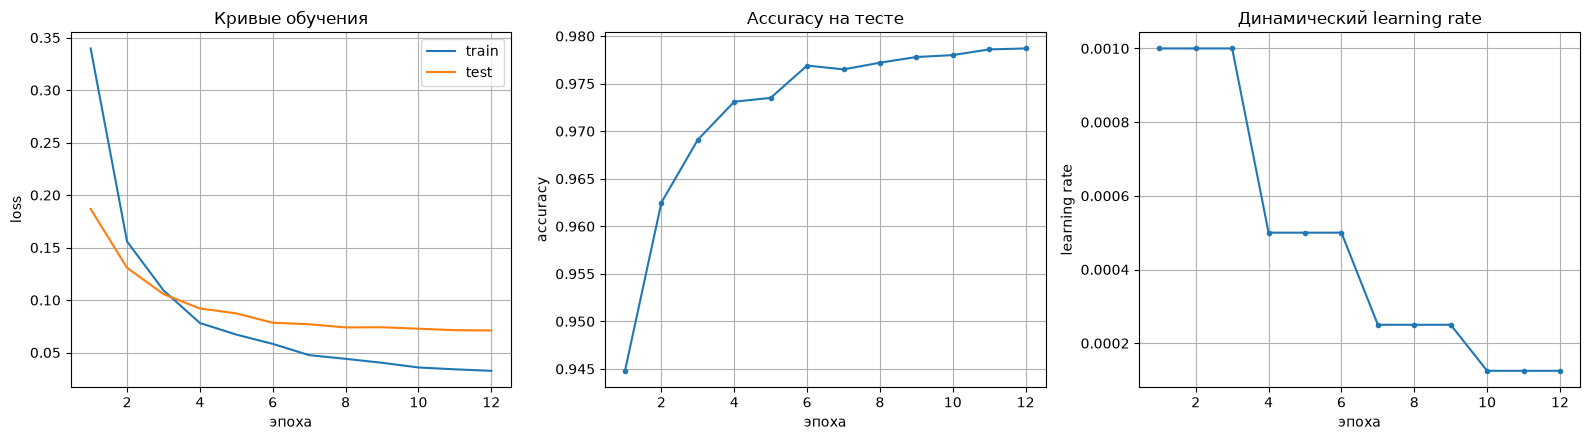

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(range(1, epochs + 1), train_loss, label="train")
axes[0].plot(range(1, epochs + 1), test_loss, label="test")
axes[0].set_title("Кривые обучения")
axes[0].set_ylabel("loss")
axes[0].legend()

axes[1].plot(range(1, epochs + 1), test_acc, marker=".")
axes[1].set_title("Accuracy на тесте")
axes[1].set_ylabel("accuracy")

axes[2].plot(range(1, epochs + 1), lrs, marker=".")
axes[2].set_title("Динамический learning rate")
axes[2].set_ylabel("learning rate")

for ax in axes:
    ax.set_xlabel("эпоха")
    ax.grid(True)

plt.tight_layout()
plt.show()

На графике lr видно ступеньки: каждые 3 эпохи шаг уменьшается вдвое. Основное падение ошибки
происходит на первых трех эпохах, пока lr большой, а дальше, с уменьшением шага, обе кривые ровно
и без скачков выходят на плато: test loss доходит до 0.071, accuracy — до 0.979. Кривая теста
не разворачивается вверх, значит переобучения за 12 эпох нет.

### Шаг 6. Зачем нужен динамический learning rate

Обучим ту же сеть с постоянным lr = 0.001 и сравним ошибку на тесте.

In [25]:
torch.manual_seed(42)

model_const = nn.Sequential(
    nn.Linear(784, 128), nn.ReLU(),
    nn.Linear(128, 10),
)
opt_const = torch.optim.Adam(model_const.parameters(), lr=0.001)

test_loss_const, test_acc_const = [], []

for ep in range(epochs):
    idx = torch.randperm(len(Xtr))
    for i in range(0, len(Xtr), batch):
        b = idx[i:i + batch]
        opt_const.zero_grad()
        loss = loss_fn(model_const(Xtr[b]), ytr[b])
        loss.backward()
        opt_const.step()

    with torch.no_grad():
        out_te = model_const(Xte)
        test_loss_const.append(loss_fn(out_te, yte).item())
        test_acc_const.append((out_te.argmax(dim=1) == yte).float().mean().item())

print("постоянный lr:      test loss =", round(test_loss_const[-1], 4),
      " test acc =", round(test_acc_const[-1], 4))
print("динамический lr:    test loss =", round(test_loss[-1], 4),
      " test acc =", round(test_acc[-1], 4))

постоянный lr:      test loss = 0.0754  test acc = 0.9783
динамический lr:    test loss = 0.0711  test acc = 0.9787


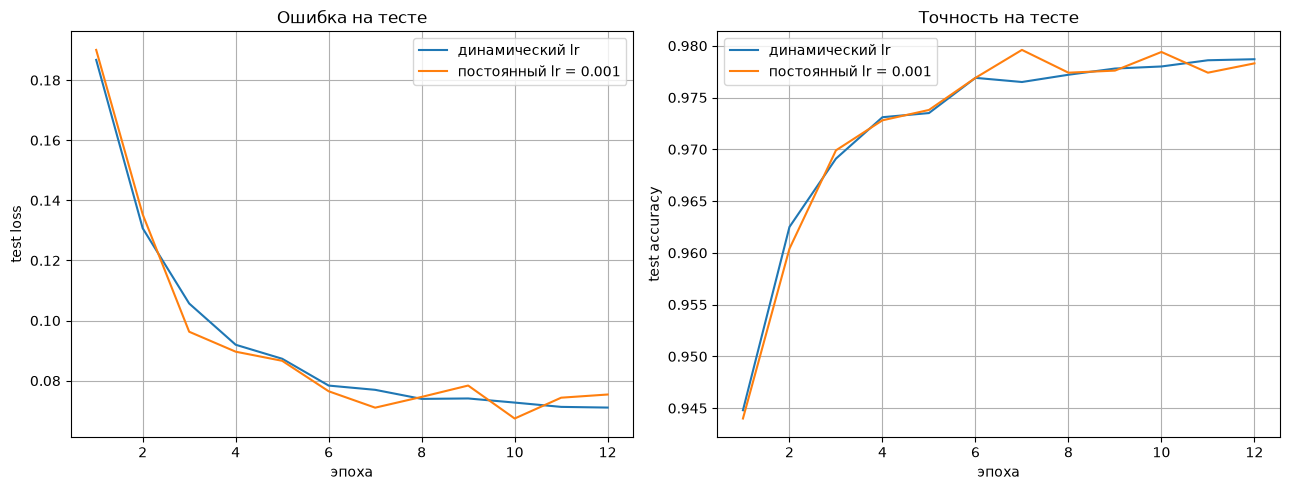

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(range(1, epochs + 1), test_loss, label="динамический lr")
axes[0].plot(range(1, epochs + 1), test_loss_const, label="постоянный lr = 0.001")
axes[0].set_ylabel("test loss")
axes[0].set_title("Ошибка на тесте")

axes[1].plot(range(1, epochs + 1), test_acc, label="динамический lr")
axes[1].plot(range(1, epochs + 1), test_acc_const, label="постоянный lr = 0.001")
axes[1].set_ylabel("test accuracy")
axes[1].set_title("Точность на тесте")

for ax in axes:
    ax.set_xlabel("эпоха")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

До 5-й эпохи обе кривые идут одинаково — на этом этапе шаг еще не успел уменьшиться. Дальше видна
разница: с постоянным lr ошибка на тесте перестает падать и начинает болтаться (0.072 -> 0.078 -> 0.068 ->
0.075), потому что большие шаги перебрасывают модель через минимум, а с уменьшающимся lr кривая
монотонно опускается и заканчивает ниже: 0.0711 против 0.0754. Accuracy при этом почти одинаковая
(0.9787 против 0.9783), так что главный эффект динамического learning rate здесь — стабильность:
результат не зависит от того, на какой эпохе мы остановились.

### Шаг 7. Метрики качества

Задача многоклассовая, поэтому Precision, Recall и F1 считаем с усреднением `macro` — по всем 10 цифрам.

In [27]:
with torch.no_grad():
    y_pred = model(Xte).argmax(dim=1).numpy()

print("Accuracy  =", round(accuracy_score(y_test, y_pred), 4))
print("Precision =", round(precision_score(y_test, y_pred, average="macro"), 4))
print("Recall    =", round(recall_score(y_test, y_pred, average="macro"), 4))
print("F1        =", round(f1_score(y_test, y_pred, average="macro"), 4))

Accuracy  = 0.9787
Precision = 0.9786
Recall    = 0.9785
F1        = 0.9785


Accuracy около 0.978 — из 10000 тестовых картинок сеть ошибается примерно на 220. Все четыре метрики
почти одинаковые, потому что классы сбалансированы и ошибки распределены по цифрам ровно.

### Шаг 8. Примеры предсказаний

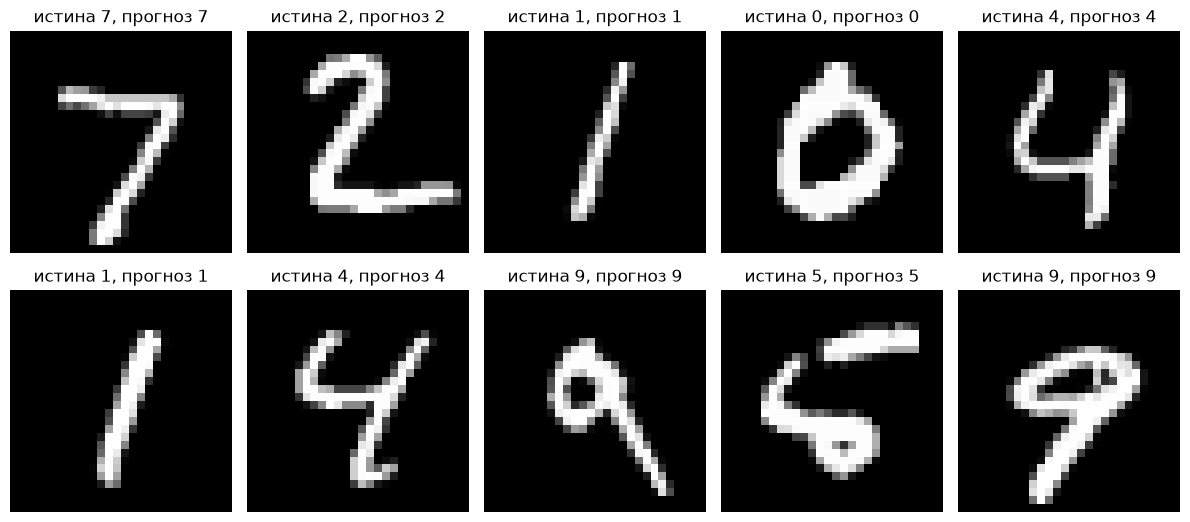

In [28]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5.5))

for ax, i in zip(axes.flatten(), range(10)):
    ax.imshow(X_test[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"истина {y_test[i]}, прогноз {y_pred[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Посмотрим и на картинки, где сеть ошиблась.

всего ошибок: 213


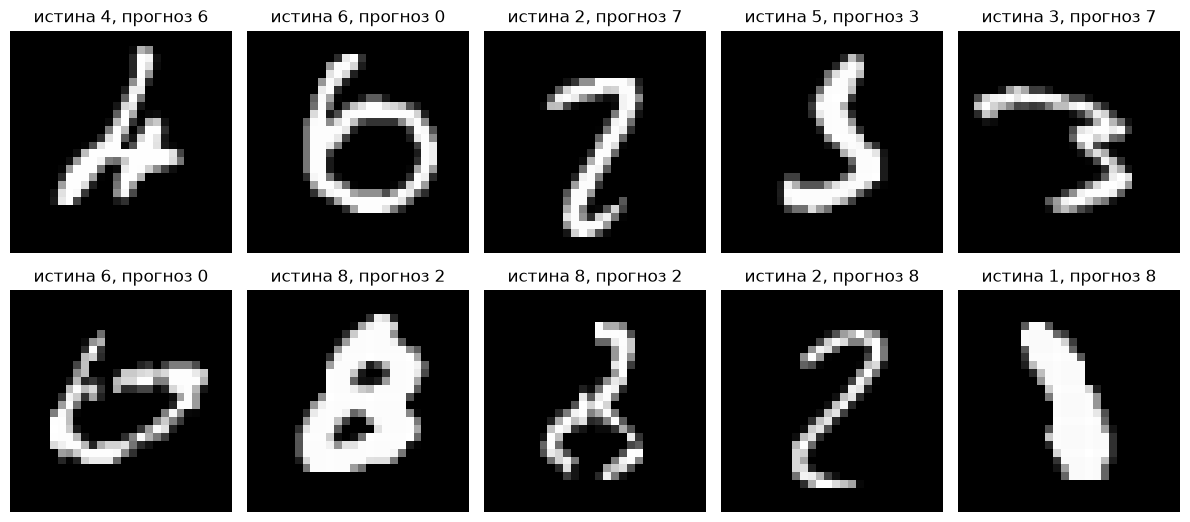

In [29]:
wrong = np.where(y_pred != y_test)[0]
print("всего ошибок:", len(wrong))

fig, axes = plt.subplots(2, 5, figsize=(12, 5.5))

for ax, i in zip(axes.flatten(), wrong[:10]):
    ax.imshow(X_test[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"истина {y_test[i]}, прогноз {y_pred[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Ошибки в основном на криво или нетипично написанных цифрах — часть из них и человек прочитает не сразу.

### Шаг 9. Матрица ошибок

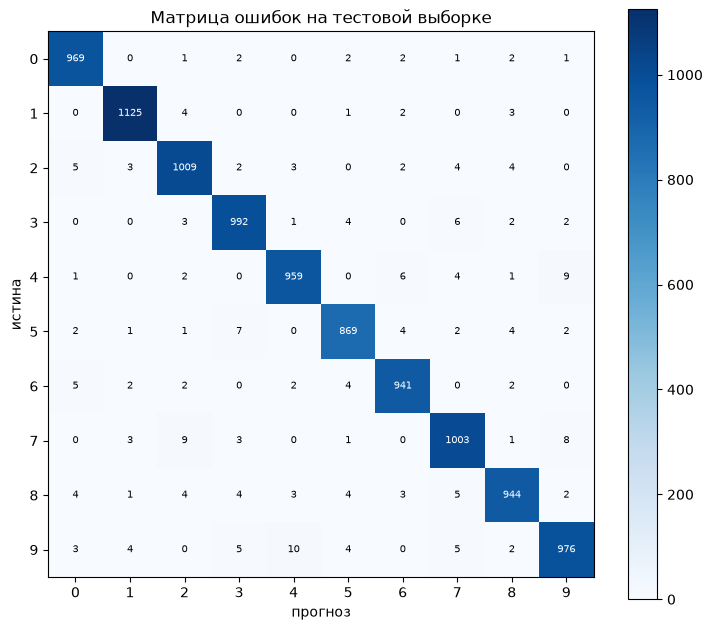

In [30]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7.5, 6.5))
plt.imshow(cm, cmap="Blues")
plt.colorbar()

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=7,
                 color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.xticks(range(10))
plt.yticks(range(10))
plt.xlabel("прогноз")
plt.ylabel("истина")
plt.title("Матрица ошибок на тестовой выборке")
plt.tight_layout()
plt.show()

In [31]:
# самые частые путаницы
err = cm.copy()
np.fill_diagonal(err, 0)

pairs = []
for i in range(10):
    for j in range(10):
        if err[i, j] > 0:
            pairs.append([i, j, err[i, j]])

pairs = pd.DataFrame(pairs, columns=["истина", "прогноз", "количество"])
pairs.sort_values("количество", ascending=False).head(6)

,истина,прогноз,количество
62,9,4,10
45,7,2,9
29,4,9,9
49,7,9,8
33,5,3,7
26,4,6,6


Основная масса значений стоит на диагонали. Ошибки приходятся на похожие по написанию цифры:
чаще всего путаются 9 и 4 (10 и 9 случаев), 7 распознается как 2 или 9, а 5 — как 3.
У этих цифр совпадают крупные части контура, и полносвязной сети, которая смотрит на пиксели
по отдельности, этого различия не хватает.

## Выводы

**Часть 1.** Две модели — с двумя выходными нейронами и categorical cross-entropy и с одним нейроном,
сигмоидой и binary cross-entropy — дали одинаковое качество (Accuracy ≈ 0.81, F1 ≈ 0.81) и практически
совпадающие цветовые карты. Для двух классов это два способа записать одну и ту же модель, так что выбор
между ними — вопрос удобства: вариант с softmax сразу обобщается на любое число классов, вариант
с сигмоидой экономит параметры в бинарной задаче. Ограничивает качество не архитектура, а сами признаки:
на коротких фрагментах отношение слов к буквам сильно шумит, и классы перекрываются.

**Часть 2.** Простая сеть 784 -> 128 -> 10 с `CrossEntropyLoss` дает на MNIST Accuracy ≈ 0.978 за 12 эпох.
Динамический learning rate (`StepLR`, уменьшение вдвое каждые 3 эпохи) сглаживает конец обучения:
с постоянным шагом ошибка на тесте перестает падать и начинает колебаться, а с уменьшающимся ровно
опускается до меньшего значения (0.0711 против 0.0754). Оставшиеся 213 ошибок — это визуально
похожие цифры (9/4, 7/2, 5/3) и просто криво написанные примеры.